## Imports

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


### Df

### Creating the df

In [2]:
df = pd.read_csv('../Datasets/dataset_ransomware_v1.csv', index_col = 0)
df.head()

,filename,sha256,num_sections,has_rsrc_section,max_entropy,avg_entropy,total_imports,suspicious_api_count,timestamp,is_dll,image_size,is_64bit,is_ransomware
0,avast.exe,6f486a9d30bc410250a27bd1b1a5b95518c70bf29be93e...,6,1,6.673007,4.746518,185,11,1726818470,0,258048,0,0
1,Windows_Credentials_Viewer.exe,501a946121cf6dc612f9ba078067392ef8c4f2f78adf79...,5,1,7.007302,5.728303,674,16,1496170115,0,4804608,0,0
2,RiotClientCrashHandler.exe,d224446bc4aed018940fe1a13e5bab2e6b98769199a612...,6,0,6.328385,4.244157,191,9,2396255610,0,917504,1,0
3,RiotClientFoundation.dll,8cf741ffcd8b2492219be0e00cc8db23e11b669615b48c...,7,1,6.636638,4.958194,440,17,380415491,1,16805888,1,0
4,RiotClientServices.exe,76282276fcaad1118c3eff19d5802747e035fe57bcd03e...,7,1,7.997690,5.343996,380,12,3586101223,0,74416128,1,0


### Analyses

In [3]:
df.describe()

,num_sections,has_rsrc_section,max_entropy,avg_entropy,total_imports,suspicious_api_count,timestamp,is_dll,image_size,is_64bit,is_ransomware
count,125.000000,125.000000,125.000000,125.000000,125.000000,125.00000,1.250000e+02,125.000000,1.250000e+02,125.000000,125.000000
mean,5.872000,0.912000,6.212319,3.655090,154.736000,4.28800,1.946104e+09,0.464000,2.608955e+06,0.768000,0.192000
std,1.507915,0.284435,1.203225,1.400214,130.362407,4.04175,1.200218e+09,0.500709,9.818495e+06,0.423808,0.395458
min,2.000000,0.000000,1.265017,0.562997,0.000000,0.00000,0.000000e+00,0.000000,2.048000e+04,0.000000,0.000000
25%,5.000000,1.000000,6.076582,2.688227,57.000000,2.00000,1.184887e+09,0.000000,9.420800e+04,1.000000,0.000000
50%,6.000000,1.000000,6.302888,3.537427,141.000000,3.00000,1.591751e+09,0.000000,2.662400e+05,1.000000,0.000000
75%,7.000000,1.000000,6.656059,4.459265,200.000000,6.00000,2.960804e+09,1.000000,7.168000e+05,1.000000,0.000000
max,11.000000,1.000000,7.999868,6.645420,718.000000,21.00000,4.244159e+09,1.000000,7.441613e+07,1.000000,1.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 125 entries, 0 to 124
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   filename              125 non-null    object 
 1   sha256                125 non-null    object 
 2   num_sections          125 non-null    int64  
 3   has_rsrc_section      125 non-null    int64  
 4   max_entropy           125 non-null    float64
 5   avg_entropy           125 non-null    float64
 6   total_imports         125 non-null    int64  
 7   suspicious_api_count  125 non-null    int64  
 8   timestamp             125 non-null    int64  
 9   is_dll                125 non-null    int64  
 10  image_size            125 non-null    int64  
 11  is_64bit              125 non-null    int64  
 12  is_ransomware         125 non-null    int64  
dtypes: float64(2), int64(9), object(2)
memory usage: 13.7+ KB


In [5]:
df_just_numbers = df.drop(["filename","sha256"], axis=1)

In [6]:
corr = df_just_numbers.corr()

In [7]:
corr

,num_sections,has_rsrc_section,max_entropy,avg_entropy,total_imports,suspicious_api_count,timestamp,is_dll,image_size,is_64bit,is_ransomware
num_sections,1.000000,0.293171,0.030809,-0.318745,0.448025,0.209873,0.024656,0.164745,0.099572,0.685073,-0.553505
has_rsrc_section,0.293171,1.000000,-0.242997,-0.367148,0.280150,0.099388,-0.065755,0.289015,0.043402,0.297572,-0.565538
max_entropy,0.030809,-0.242997,1.000000,0.741048,0.247253,0.279995,0.072213,-0.292652,0.207689,-0.412914,0.372503
avg_entropy,-0.318745,-0.367148,0.741048,1.000000,0.207997,0.320320,0.064031,-0.281542,0.212363,-0.636216,0.532665
total_imports,0.448025,0.280150,0.247253,0.207997,1.000000,0.685356,-0.095765,0.084052,0.347377,0.214769,-0.341282
suspicious_api_count,0.209873,0.099388,0.279995,0.320320,0.685356,1.000000,-0.179877,-0.002805,0.471513,-0.021883,-0.150922
timestamp,0.024656,-0.065755,0.072213,0.064031,-0.095765,-0.179877,1.000000,-0.104240,0.038950,0.029340,-0.076561
is_dll,0.164745,0.289015,-0.292652,-0.281542,0.084052,-0.002805,-0.104240,1.000000,-0.073205,0.397365,-0.412818
image_size,0.099572,0.043402,0.207689,0.212363,0.347377,0.471513,0.038950,-0.073205,1.000000,-0.014919,0.042036
is_64bit,0.685073,0.297572,-0.412914,-0.636216,0.214769,-0.021883,0.029340,0.397365,-0.014919,1.000000,-0.742560


<Axes: >

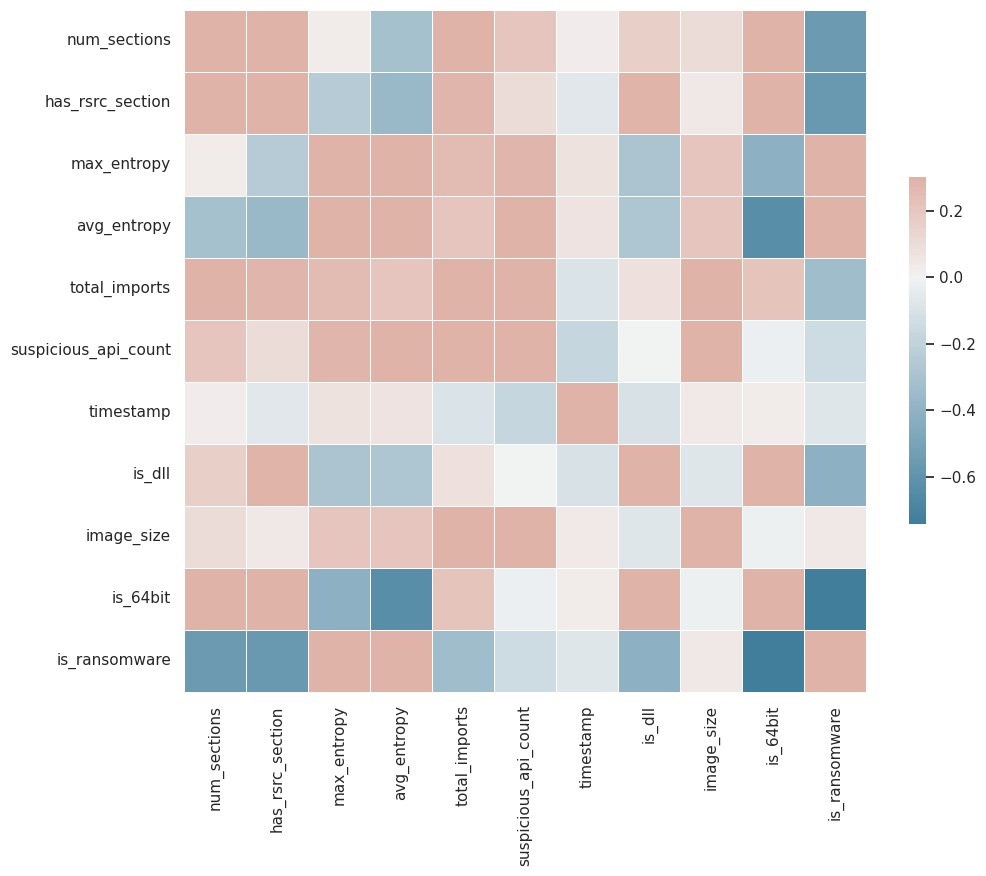

In [8]:
sns.set_theme(style="white")

# Set up the matplotlib figure

f, ax = plt.subplots(figsize=(11, 9))

cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr,cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

In [9]:
df_just_the_good_features = df_just_numbers[["num_sections","has_rsrc_section","max_entropy","avg_entropy","is_dll","is_64bit","is_ransomware"]]

In [10]:
df_just_the_good_features.corr()

,num_sections,has_rsrc_section,max_entropy,avg_entropy,is_dll,is_64bit,is_ransomware
num_sections,1.000000,0.293171,0.030809,-0.318745,0.164745,0.685073,-0.553505
has_rsrc_section,0.293171,1.000000,-0.242997,-0.367148,0.289015,0.297572,-0.565538
max_entropy,0.030809,-0.242997,1.000000,0.741048,-0.292652,-0.412914,0.372503
avg_entropy,-0.318745,-0.367148,0.741048,1.000000,-0.281542,-0.636216,0.532665
is_dll,0.164745,0.289015,-0.292652,-0.281542,1.000000,0.397365,-0.412818
is_64bit,0.685073,0.297572,-0.412914,-0.636216,0.397365,1.000000,-0.742560
is_ransomware,-0.553505,-0.565538,0.372503,0.532665,-0.412818,-0.742560,1.000000
